In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr

from afolu.defs.assets.constants import LABEL_LIST

In [3]:
sent_path = Path("./pred")

In [5]:
mats, cities = [], []
for path in (sent_path / "transitions").glob("*.csv"):
    df = pd.read_csv(path).set_index("time_period")
    df.columns = df.columns.str.replace("pij_lndu_", "").str.split("_to_", expand=True)
    df.columns.names = ["start", "end"]
    full_cols = pd.MultiIndex.from_product(
        [LABEL_LIST, LABEL_LIST], names=["start", "end"]
    )
    df = df.reindex(columns=full_cols, fill_value=0)

    mats.append(df.to_numpy().reshape(len(df), len(LABEL_LIST), len(LABEL_LIST)))
    cities.append(path.stem)

arr = xr.DataArray(
    np.stack(mats, axis=0),
    dims=["city", "time_period", "start", "end"],
    coords={
        "city": pd.Index(cities),
        "time_period": df.index,
        "start": pd.Index(LABEL_LIST),
        "end": pd.Index(LABEL_LIST),
    },
)

In [24]:
mats, cities = [], []
for path in (sent_path / "areas").glob("*.csv"):
    df_area = pd.read_csv(path).set_index("label").transpose()
    df_area.index.name = "time_period"
    df_area = df_area.reindex(columns=pd.Index(LABEL_LIST), fill_value=0).multiply(
        10_000
    )

    mats.append(df_area.to_numpy())
    cities.append(path.stem)

arr_area = xr.DataArray(
    np.stack(mats, axis=0),
    dims=["city", "time_period", "label"],
    coords={
        "city": pd.Index(cities),
        "time_period": df_area.index.astype(int),
        "label": pd.Index(LABEL_LIST),
    },
)

In [59]:
arr_transition = (arr / arr.sum(dim="end")).fillna(0)

zero_rows = arr_transition.sum(dim="end") == 0
diagonal = arr_transition["start"] == arr_transition["end"]
mask = zero_rows & diagonal
arr_transition = arr_transition.where(~mask, 1)

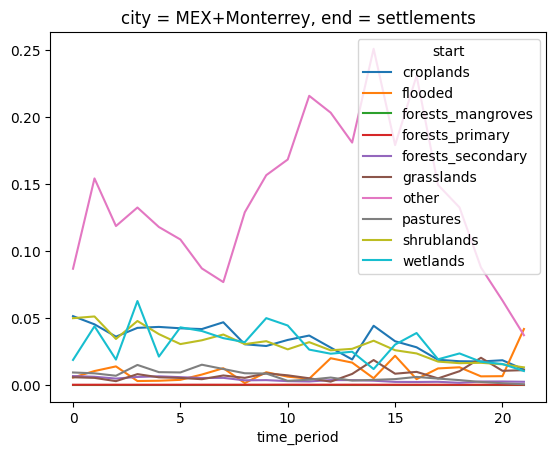

In [66]:
arr_transition.sel(city="MEX+Monterrey", end="settlements").drop_sel(
    start="settlements"
).plot.line(x="time_period")

In [46]:
mask

<xarray.DataArray (city: 67, time_period: 22, start: 11, end: 11)> Size: 178kB
array([[[[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         ...,
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]],

        [[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         ...,
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]],

        [[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         ...,
...
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]],

        [[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False,  True, ..., False, False, False],
         ...,
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]],

        [[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False,  True, ..., False, False, False],
         ...,
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]]]],
      shape=(67, 22, 11, 11))
Coordinates:
  * city         (city) object 536B 'MEX+Acapulco' ... 'MEX+Zamora'
  * time_period  (time_period) int64 176B 0 1 2 3 4 5 6 ... 15 16 17 18 19 20 21
  * start        (start) object 88B 'croplands' 'flooded' ... 'wetlands'
  * end          (end) object 88B 'croplands' 'flooded' ... 'wetlands'

In [44]:
arr_transition.sum(dim="end")

<xarray.DataArray (city: 67, time_period: 22, start: 11)> Size: 130kB
array([[[1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        ...,
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.]],

       [[1., 1., 0., ..., 1., 1., 1.],
        [1., 1., 0., ..., 1., 1., 1.],
        [1., 1., 0., ..., 1., 1., 1.],
        ...,
        [1., 1., 0., ..., 1., 1., 1.],
        [1., 1., 0., ..., 1., 1., 1.],
        [1., 1., 0., ..., 1., 1., 1.]],

       [[1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        ...,
...
        ...,
        [1., 1., 0., ..., 1., 1., 1.],
        [1., 1., 0., ..., 1., 1., 1.],
        [1., 1., 0., ..., 1., 1., 1.]],

       [[1., 1., 0., ..., 1., 1., 1.],
        [1., 1., 0., ..., 1., 1., 1.],
        [1., 1., 0., ..., 1., 1., 1.],
        ...,
        [1., 1., 0., ..., 1., 1., 1.],
        [1., 1., 0., ..., 1., 1., 1.],
        [1., 1., 0., ..., 1., 1., 1.]],

       [[1., 1., 0., ..., 1., 1., 1.],
        [1., 1., 0., ..., 1., 1., 1.],
        [1., 1., 0., ..., 1., 1., 1.],
        ...,
        [1., 1., 0., ..., 1., 1., 1.],
        [1., 1., 0., ..., 1., 1., 1.],
        [1., 1., 0., ..., 1., 1., 1.]]], shape=(67, 22, 11))
Coordinates:
  * city         (city) object 536B 'MEX+Acapulco' ... 'MEX+Zamora'
  * time_period  (time_period) int64 176B 0 1 2 3 4 5 6 ... 15 16 17 18 19 20 21
  * start        (start) object 88B 'croplands' 'flooded' ... 'wetlands'

In [ ]:
arr_transition.where(arr_transition.sum(dim="end") == 0, drop=True).sel(
    city="MEX+Monterrey", time_period=0
)

<xarray.DataArray (start: 4, end: 11)> Size: 352B
array([[ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]])
Coordinates:
  * start        (start) object 32B 'forests_mangroves' ... 'pastures'
  * end          (end) object 88B 'croplands' 'flooded' ... 'wetlands'
    city         <U13 52B 'MEX+Monterrey'
    time_period  int64 8B 0

In [18]:
arr.sel(city="MEX+Monterrey", time_period=0).sum(dim="end")

<xarray.DataArray (start: 11)> Size: 88B
array([3.59335103e+08, 4.60796490e+06, 0.00000000e+00, 2.97835028e+08,
       1.24974110e+09, 5.73143096e+06, 8.48837534e+06, 4.52958206e+07,
       5.72384077e+08, 7.38733214e+08, 8.71157810e+05])
Coordinates:
  * start        (start) object 88B 'croplands' 'flooded' ... 'wetlands'
    city         <U13 52B 'MEX+Monterrey'
    time_period  int64 8B 0

In [25]:
arr_area.sel(city="MEX+Monterrey", time_period=0)

<xarray.DataArray (label: 11)> Size: 88B
array([3.58511595e+08, 4.60796490e+06, 1.00000000e+03, 2.97835028e+08,
       1.24974110e+09, 5.73143096e+06, 8.48837534e+06, 4.52958206e+07,
       5.72384077e+08, 7.38733214e+08, 8.71157810e+05])
Coordinates:
  * label        (label) object 88B 'croplands' 'flooded' ... 'wetlands'
    city         <U13 52B 'MEX+Monterrey'
    time_period  int64 8B 0

In [8]:
arr.sel(city="MEX+Monterrey", time_period=0)

<xarray.DataArray (start: 11, end: 11)> Size: 968B
array([[3.14229201e+08, 2.86446276e+04, 0.00000000e+00, 1.29583118e+04,
        9.81638330e+06, 6.33293676e+05, 1.72719232e+05, 4.18690534e+06,
        1.84138138e+07, 1.17690801e+07, 7.21037423e+04],
       [2.42259424e+03, 4.52803097e+06, 0.00000000e+00, 0.00000000e+00,
        1.13048184e+04, 0.00000000e+00, 5.64968286e+03, 0.00000000e+00,
        2.50262534e+04, 1.77626336e+04, 1.77679458e+04],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.29520975e+04, 8.09587585e+02, 0.00000000e+00, 2.97806707e+08,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        4.85500146e+03, 9.70352386e+03, 0.00000000e+00],
       [1.15749072e+07, 2.26218023e+04, 0.00000000e+00, 0.00000000e+00,
        1.22262107e+09, 1.81804307e+05, 1.53598499e+04, 2.22154230e+06,
        8.13695463e+06, 4.81986372e+06, 1.46975506e+05],
       [1.04864415e+06, 8.06988892e+02, 0.00000000e+00, 0.00000000e+00,
        2.38878879e+05, 4.22609326e+06, 3.22937244e+03, 0.00000000e+00,
        3.21642540e+04, 1.81614058e+05, 0.00000000e+00],
       [3.22883961e+04, 4.03581287e+03, 0.00000000e+00, 0.00000000e+00,
        1.45516068e+04, 1.04939055e+04, 6.88115410e+06, 0.00000000e+00,
        7.35258432e+05, 8.07359346e+05, 3.23373285e+03],
       [6.88927843e+06, 0.00000000e+00, 0.00000000e+00, 8.07849792e+02,
        8.76432130e+05, 0.00000000e+00, 6.45099866e+03, 3.23919131e+07,
        4.16110182e+05, 4.71401843e+06, 8.09454895e+02],
       [7.40062140e+06, 3.39165860e+04, 0.00000000e+00, 2.42729474e+03,
        3.13238326e+06, 2.87579932e+04, 7.23502885e+05, 1.26052680e+05,
        5.43175511e+08, 1.77213320e+07, 3.95715328e+04],
       [2.40881721e+07, 1.83299488e+05, 0.00000000e+00, 7.27656384e+03,
        1.63191301e+07, 2.46897912e+05, 2.75949476e+05, 1.35444406e+06,
        3.67260296e+07, 6.59479512e+08, 5.25025698e+04],
       [2.58385458e+04, 7.59948981e+04, 0.00000000e+00, 0.00000000e+00,
        6.70438350e+04, 0.00000000e+00, 1.61469379e+03, 0.00000000e+00,
        1.61555687e+04, 3.71736642e+04, 6.47336604e+05]])
Coordinates:
  * start        (start) object 88B 'croplands' 'flooded' ... 'wetlands'
  * end          (end) object 88B 'croplands' 'flooded' ... 'wetlands'
    city         <U13 52B 'MEX+Monterrey'
    time_period  int64 8B 0

In [ ]:
temp.sel(time_period=0, city="MEX+Monterrey").to_numpy().sum(axis=1)

array([1.11298593e-01, 1.48624692e-03, 0.00000000e+00, 9.07409994e-02,
       3.81785658e-01, 1.62310030e-03, 2.46347828e-03, 1.22725148e-02,
       1.85144640e-01, 2.13136694e-01, 2.98671885e-04])

In [99]:
arr.sel(city="MEX+Monterrey", time_period=0)

<xarray.DataArray (start: 11, end: 11)> Size: 968B
array([[3.14229201e+08, 2.86446276e+04, 0.00000000e+00, 1.29583118e+04,
        9.81638330e+06, 6.33293676e+05, 1.72719232e+05, 4.18690534e+06,
        1.84138138e+07, 1.17690801e+07, 7.21037423e+04],
       [2.42259424e+03, 4.52803097e+06, 0.00000000e+00, 0.00000000e+00,
        1.13048184e+04, 0.00000000e+00, 5.64968286e+03, 0.00000000e+00,
        2.50262534e+04, 1.77626336e+04, 1.77679458e+04],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.29520975e+04, 8.09587585e+02, 0.00000000e+00, 2.97806707e+08,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        4.85500146e+03, 9.70352386e+03, 0.00000000e+00],
       [1.15749072e+07, 2.26218023e+04, 0.00000000e+00, 0.00000000e+00,
        1.22262107e+09, 1.81804307e+05, 1.53598499e+04, 2.22154230e+06,
        8.13695463e+06, 4.81986372e+06, 1.46975506e+05],
       [1.04864415e+06, 8.06988892e+02, 0.00000000e+00, 0.00000000e+00,
        2.38878879e+05, 4.22609326e+06, 3.22937244e+03, 0.00000000e+00,
        3.21642540e+04, 1.81614058e+05, 0.00000000e+00],
       [3.22883961e+04, 4.03581287e+03, 0.00000000e+00, 0.00000000e+00,
        1.45516068e+04, 1.04939055e+04, 6.88115410e+06, 0.00000000e+00,
        7.35258432e+05, 8.07359346e+05, 3.23373285e+03],
       [6.88927843e+06, 0.00000000e+00, 0.00000000e+00, 8.07849792e+02,
        8.76432130e+05, 0.00000000e+00, 6.45099866e+03, 3.23919131e+07,
        4.16110182e+05, 4.71401843e+06, 8.09454895e+02],
       [7.40062140e+06, 3.39165860e+04, 0.00000000e+00, 2.42729474e+03,
        3.13238326e+06, 2.87579932e+04, 7.23502885e+05, 1.26052680e+05,
        5.43175511e+08, 1.77213320e+07, 3.95715328e+04],
       [2.40881721e+07, 1.83299488e+05, 0.00000000e+00, 7.27656384e+03,
        1.63191301e+07, 2.46897912e+05, 2.75949476e+05, 1.35444406e+06,
        3.67260296e+07, 6.59479512e+08, 5.25025698e+04],
       [2.58385458e+04, 7.59948981e+04, 0.00000000e+00, 0.00000000e+00,
        6.70438350e+04, 0.00000000e+00, 1.61469379e+03, 0.00000000e+00,
        1.61555687e+04, 3.71736642e+04, 6.47336604e+05]])
Coordinates:
  * start        (start) object 88B 'croplands' 'flooded' ... 'wetlands'
  * end          (end) object 88B 'croplands' 'flooded' ... 'wetlands'
    city         <U13 52B 'MEX+Monterrey'
    time_period  int64 8B 0

In [5]:
probs = pd.concat(sett_series, axis=1)

In [6]:
probs

,MEX+Acapulco,MEX+Aguascalientes,MEX+Campeche,MEX+Celaya,MEX+Chetumal,MEX+Chihuahua,MEX+Chilpancingo,MEX+Ciudad de México,MEX+Ciudad Juárez,MEX+Ciudad Obregón,...,MEX+Tlaxcala-Apizaco,MEX+Toluca,MEX+Tulancingo,MEX+Tuxtla Gutiérrez,MEX+Uruapan,MEX+Veracruz,MEX+Villahermosa,MEX+Xalapa,MEX+Zacatecas-Guadalupe,MEX+Zamora
time_period,,,,,,,,,,,,,,,,,,,,,
0,0.006375,0.011898,0.004657,0.008574,0.003214,0.008846,0.004725,0.013423,0.016049,0.005033,...,0.009906,0.013678,0.008747,0.007618,0.004921,0.008521,0.008990,0.005921,0.004902,0.004531
1,0.006265,0.011141,0.005112,0.008428,0.003668,0.010124,0.003380,0.020204,0.011985,0.004956,...,0.006817,0.012244,0.007900,0.006473,0.003743,0.008382,0.008885,0.007412,0.010319,0.007266
2,0.006131,0.012389,0.003237,0.013665,0.005560,0.008182,0.004653,0.022159,0.013172,0.004534,...,0.010912,0.018959,0.009542,0.006399,0.003654,0.010072,0.008748,0.008592,0.006296,0.006906
3,0.005287,0.011486,0.002319,0.010710,0.004081,0.010134,0.002973,0.014078,0.014657,0.005582,...,0.009491,0.017861,0.005308,0.008349,0.004037,0.010029,0.010620,0.004679,0.006197,0.005785
4,0.005767,0.011738,0.002875,0.011438,0.003193,0.008015,0.002537,0.016056,0.013774,0.005172,...,0.010101,0.017167,0.009046,0.007332,0.003914,0.012271,0.004587,0.008652,0.004631,0.003679
5,0.007215,0.008439,0.002831,0.010743,0.003972,0.007632,0.003305,0.014671,0.012187,0.004599,...,0.006294,0.015015,0.007882,0.006478,0.002966,0.011105,0.007347,0.006792,0.003331,0.004243
6,0.008043,0.007989,0.004549,0.008290,0.003823,0.006980,0.004780,0.014117,0.011213,0.004964,...,0.010996,0.020177,0.008883,0.006686,0.002809,0.008250,0.005364,0.006596,0.004457,0.004338
7,0.006099,0.008231,0.003620,0.007503,0.004748,0.006265,0.003746,0.011273,0.007314,0.004030,...,0.005855,0.011977,0.006338,0.006474,0.002798,0.012021,0.007358,0.008350,0.006205,0.005435
8,0.007094,0.006775,0.003578,0.008010,0.004295,0.004788,0.004413,0.012584,0.006792,0.003277,...,0.008944,0.014560,0.005715,0.005679,0.002643,0.018737,0.006178,0.006939,0.004529,0.003858


<Axes: xlabel='time_period'>

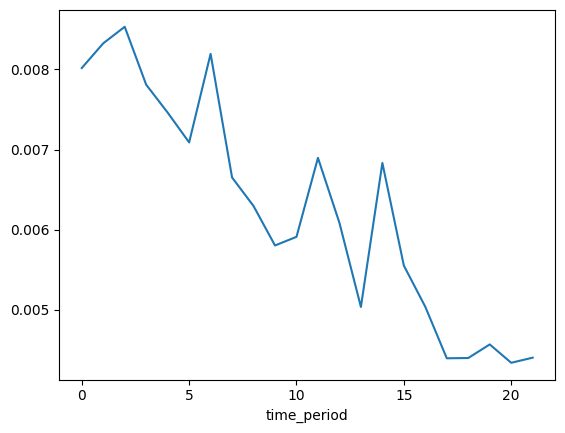

In [61]:
probs.mean(axis=1).plot(legend=False)